In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Matplotlib is the core plotting library
# Seaborn is built on top of matplotlib and provides
# better defaults and easier statistical plots
plt.style.use("seaborn-v0_8")

In [ ]:
PROJECT_ROOT = Path().resolve().parent #the .resolve() method belongs to the pathlib.Path objects. It is used to make a path absolute, resolve any symbolic links, and eliminate "." (current directory) and ".." (parent directory) components to return the canonical path to a file system item. 
weather_path = PROJECT_ROOT / "data" / "raw" / "weather" #Get global path of all weather cities

dfs = [] # to store all df containing each city's data
for city_path in weather_path.glob("*_weather_2015.csv"):  #glob method allows you to find pathnames matching a specified pattern
    city = city_path.stem.replace("_weather_2015", "") # stem as the names suggest the get the stem (file name) from the relative or absolute path
    df = pd.read_csv(city_path)
    df["city"] = city
    dfs.append(df)

weather_data = pd.concat(dfs, ignore_index=True) #ignore index tells to use default indexing
weather_data["date"] = pd.to_datetime(weather_data["date"])
print(weather_data.head())

        date  temperature  wind_speed  rainfall  pressure       city
0 2018-01-01         24.2         NaN       NaN       NaN  hyderabad
1 2018-01-02         23.8         7.7       NaN       NaN  hyderabad
2 2018-01-03         23.5         8.3       NaN       NaN  hyderabad
3 2018-01-04         22.8         7.8       NaN       NaN  hyderabad
4 2018-01-05         22.2         9.1       NaN       NaN  hyderabad


In [87]:
weather_data.size

65730

In [88]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10955 entries, 0 to 10954
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         10955 non-null  datetime64[ns]
 1   temperature  10955 non-null  float64       
 2   wind_speed   10748 non-null  float64       
 3   rainfall     7196 non-null   float64       
 4   pressure     9840 non-null   float64       
 5   city         10955 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 513.6+ KB


In [89]:
weather_data.describe()


,date,temperature,wind_speed,rainfall,pressure
count,10955,10955.000000,10748.000000,7196.000000,9840.000000
mean,2020-12-31 00:00:00,26.287467,8.340631,6.364216,1009.269604
min,2018-01-01 00:00:00,6.900000,0.300000,0.000000,989.600000
25%,2019-07-02 00:00:00,23.600000,5.300000,0.000000,1005.700000
50%,2020-12-31 00:00:00,26.900000,7.900000,0.000000,1009.900000
75%,2022-07-02 00:00:00,29.500000,10.500000,3.925000,1013.400000
max,2023-12-31 00:00:00,39.200000,30.400000,374.900000,1024.500000
std,NaN,4.580960,4.214290,19.103678,5.368115


In [90]:
#Percentage of missing rows 
weather_data.isna().mean() * 100

date            0.000000
temperature     0.000000
wind_speed      1.889548
rainfall       34.313099
pressure       10.178001
city            0.000000
dtype: float64

In [91]:
weather_data["rainfall"].fillna(0, inplace=True)

weather_data["wind_speed"].fillna(method="ffill", inplace=True)

weather_data.interpolate(method="linear", inplace=True)

weather_data.fillna(method="bfill", inplace=True)

weather_data.isna().mean() * 100


/var/folders/63/v_8k7tn55d54bf9ywgslsjzm0000gn/T/ipykernel_97954/1508594393.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  weather_data["rainfall"].fillna(0, inplace=True)
/var/folders/63/v_8k7tn55d54bf9ywgslsjzm0000gn/T/ipykernel_97954/1508594393.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

date           0.0
temperature    0.0
wind_speed     0.0
rainfall       0.0
pressure       0.0
city           0.0
dtype: float64

In [92]:
weather_data.head()

,date,temperature,wind_speed,rainfall,pressure,city
0,2018-01-01,24.2,7.7,0.0,1002.7,hyderabad
1,2018-01-02,23.8,7.7,0.0,1002.7,hyderabad
2,2018-01-03,23.5,8.3,0.0,1002.7,hyderabad
3,2018-01-04,22.8,7.8,0.0,1002.7,hyderabad
4,2018-01-05,22.2,9.1,0.0,1002.7,hyderabad


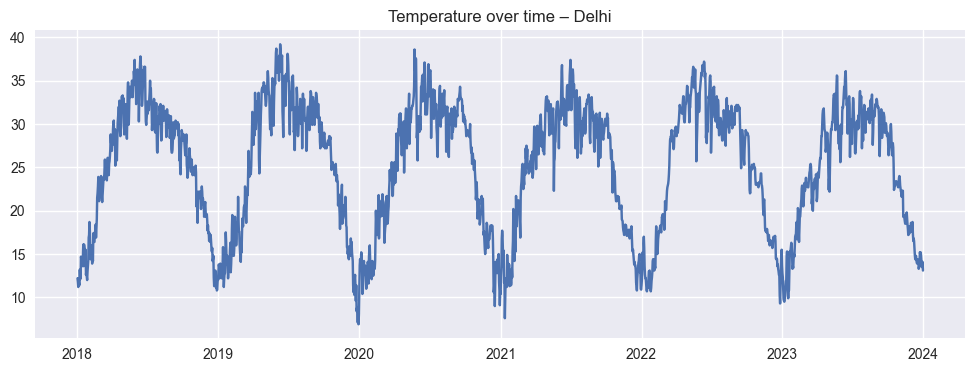

In [93]:
city = "delhi"
#we create a specific city df by using condition on weather_data
city_df = weather_data[weather_data["city"]==city]
#plot the date vs temp
plt.figure(figsize=(12,4))
plt.plot(city_df["date"], city_df["temperature"])
plt.title(f"Temperature over time – {city.title()}")
plt.show()

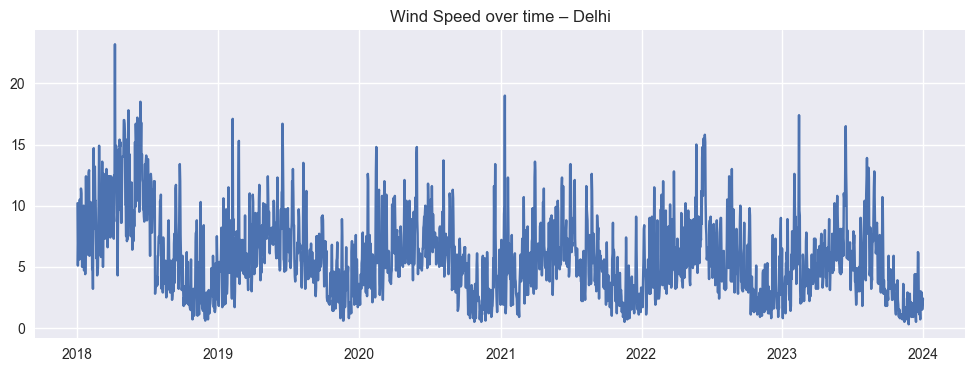

In [94]:
plt.figure(figsize=(12,4))
plt.plot(city_df["date"], city_df["wind_speed"])
plt.title(f"Wind Speed over time – {city.title()}")
plt.show()

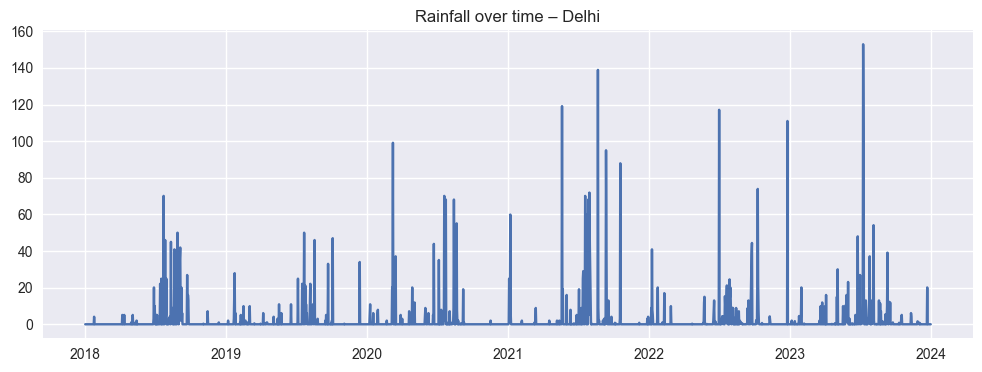

In [95]:
plt.figure(figsize=(12,4))
plt.plot(city_df["date"], city_df["rainfall"])
plt.title(f"Rainfall over time – {city.title()}")
plt.show()

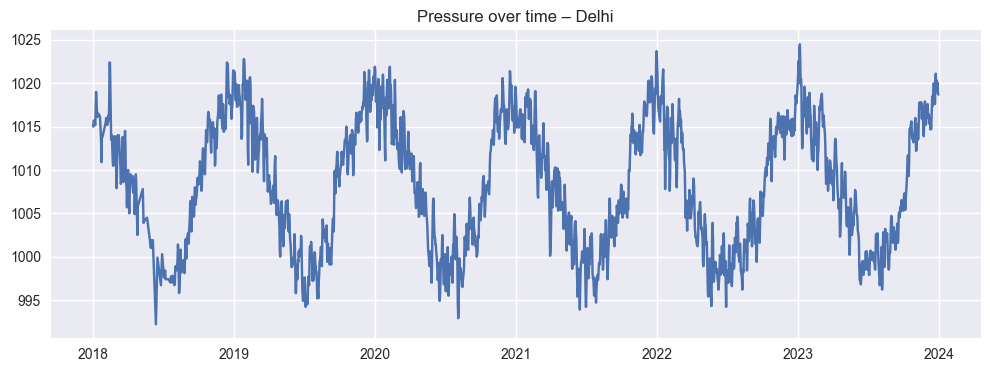

In [96]:
plt.figure(figsize=(12,4))
plt.plot(city_df["date"], city_df["pressure"])
plt.title(f"Pressure over time – {city.title()}")
plt.show()

In [97]:
weather_data.to_csv(f"{PROJECT_ROOT}/data/processed/weather_data.csv")